In [1]:
from collections import defaultdict

import numpy as np
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import torchlogix

In [2]:
def evaluate_model(model, loader, eval_functions, mode="eval"):
    """Evaluate model on a data loader with given evaluation functions.
    Assumes metrics can be computed in batches and averaged."""
    orig_mode = model.training
    model.train(mode == "train")

    metrics = defaultdict(list)

    with torch.no_grad():
        for x, y in loader:
            preds = model(x)

            for name, fn in eval_functions.items():
                metrics[name].append(fn(preds, y).to(torch.float32).mean().item())

    model.train(orig_mode)

    return {name: np.mean(vals) for name, vals in metrics.items()}


def load_n(loader, n):
    i = 0
    while i < n:
        for x in loader:
            yield x
            i += 1
            if i == n:
                break

In [3]:
transform = transforms.ToTensor()
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

In [4]:
batch_size = 128
train_loader = DataLoader(dataset=train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(dataset=test_dataset, batch_size=batch_size, shuffle=False)

In [18]:
from torchlogix.layers import LogicDense, LogicConv2d, GroupSum, FixedBinarization, OrPooling2d

model = torch.nn.Sequential(
    FixedBinarization(thresholds=[0.0]),  # binarize to a single bit
    LogicConv2d(in_dim=28, channels=1, num_kernels=16, tree_depth=2, receptive_field_size=3),  # 
    OrPooling2d(kernel_size=2, stride=2, padding=0),  # Reduce dimensionality with pooling operation
    torch.nn.Flatten(),
    LogicDense(16*13*13, 4_000),
    LogicDense(4_000, 4_000),
    GroupSum(k=10, tau=8)  # classify into ten classes
)


In [19]:
loss_fn = torch.nn.CrossEntropyLoss()
# Create evaluation functions
eval_functions = {
    "loss": loss_fn,
    "acc": lambda preds, y: (preds.argmax(-1) == y).to(torch.float32).mean(),
}
optimizer = torch.optim.Adam(model.parameters(), lr=2e-2)

In [20]:
num_iterations = 1000
eval_freq = 100
running_train_loss, n = 0.0, 0
metrics_dict = {"step": [], "test_acc_discrete": [], "test_loss_discrete": [], "test_acc_relaxed": [], "test_loss_relaxed": [], "train_loss": []}
for i, (x, y) in enumerate(load_n(train_loader, num_iterations)):
    model.train()
    x = model(x)
    loss = loss_fn(x, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    n += y.size(0)
    running_train_loss += loss
    # Evaluation
    if (eval_freq > 0 and ((i + 1) % eval_freq == 0)):
        # Evaluate on validation set
        discrete_metrics = evaluate_model(
            model, test_loader, eval_functions, mode="eval"
        )
        relaxed_metrics = evaluate_model(
            model, test_loader, eval_functions, mode="train"
        )

        metrics = \
            {f"test_{k}_discrete": v for k, v in discrete_metrics.items()} | \
            {f"test_{k}_relaxed": v for k, v in relaxed_metrics.items()} | \
            {"train_loss": running_train_loss.cpu().detach().item() / n * len(test_loader)}

        for k, v in metrics.items():
            metrics_dict[k].append(v)
        metrics_dict["step"].append(i + 1)

        print(f"Iteration {i + 1:6d} | " +
                " | ".join([f"{k}: {v:.4f}" for k, v in metrics.items()]))

        running_train_loss, n = 0.0, 0

Iteration    100 | test_loss_discrete: 2.9870 | test_acc_discrete: 0.0716 | test_loss_relaxed: 0.7231 | test_acc_relaxed: 0.8178 | train_loss: 0.9061
Iteration    200 | test_loss_discrete: 1.0228 | test_acc_discrete: 0.6974 | test_loss_relaxed: 0.4514 | test_acc_relaxed: 0.8762 | train_loss: 0.3567
Iteration    300 | test_loss_discrete: 0.5860 | test_acc_discrete: 0.8229 | test_loss_relaxed: 0.3738 | test_acc_relaxed: 0.8931 | train_loss: 0.2639
Iteration    400 | test_loss_discrete: 0.4621 | test_acc_discrete: 0.8586 | test_loss_relaxed: 0.3370 | test_acc_relaxed: 0.9017 | train_loss: 0.2312
Iteration    500 | test_loss_discrete: 0.4250 | test_acc_discrete: 0.8712 | test_loss_relaxed: 0.3151 | test_acc_relaxed: 0.9102 | train_loss: 0.2106
Iteration    600 | test_loss_discrete: 0.3783 | test_acc_discrete: 0.8823 | test_loss_relaxed: 0.2961 | test_acc_relaxed: 0.9150 | train_loss: 0.1908
Iteration    700 | test_loss_discrete: 0.3658 | test_acc_discrete: 0.8853 | test_loss_relaxed: 0.285

Text(0.5, 0.01, 'Training Step')

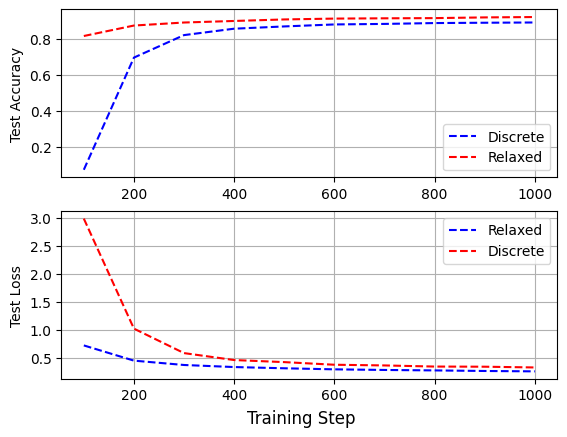

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 1)
axs[0].plot(metrics_dict["step"], metrics_dict["test_acc_discrete"], "--", c="b", label="Discrete")
axs[0].plot(metrics_dict["step"], metrics_dict["test_acc_relaxed"], "--", c="r", label="Relaxed")
axs[0].set_ylabel("Test Accuracy")
axs[0].grid()
axs[0].legend()
axs[1].plot(metrics_dict["step"], metrics_dict["test_loss_relaxed"], "--", c="b", label="Relaxed")
axs[1].plot(metrics_dict["step"], metrics_dict["test_loss_discrete"], "--", c="r", label="Discrete")
axs[1].legend()
axs[1].set_ylabel("Test Loss")
axs[1].grid()
fig.supxlabel("Training Step")

In [22]:
# Entire test set as a single batch for later use
all_X = []
for x, y in test_loader:
    all_X.append(x)
all_X = torch.cat(all_X, dim=0)

In [26]:
from torchlogix import CompiledLogicNet
from datetime import datetime

model.eval()

compiled_model = CompiledLogicNet(model, input_shape=(1, 28, 28), use_bitpacking=False, num_bits=1)
compiled_model.compile(verbose=True)

t0 = datetime.now()
all_preds = model(all_X)
print("Time for original model:", datetime.now() - t0)

t0 = datetime.now()
all_preds_compiled = compiled_model(all_X)
print("Time for compiled model:", datetime.now() - t0)

assert torch.allclose(all_preds, all_preds_compiled, atol=1e-4), "Predictions do not match!"

C code created with 94599 lines. (temp location /var/folders/c0/9f43s3c12sn447zr9wy8pp3c0000gn/T/tmpwzh254r7.c)
Compiling finished in 4.577 seconds.
Time for original model: 0:00:03.264502
Time for compiled model: 0:00:00.027569


In [32]:
# without thresholding, we can use bitpacking for the input, which is even faster

model_wo_thresholding = model[1:]

all_X_thresholded = (all_X > 0.0).bool().numpy()

compiled_model_wo_thresholding = CompiledLogicNet(model_wo_thresholding, input_shape=(1, 28, 28), use_bitpacking=True, num_bits=64)
compiled_model_wo_thresholding.compile(verbose=True)

t0 = datetime.now()
all_preds_wo_thresholding_compiled = compiled_model_wo_thresholding(all_X_thresholded)
print("Time for compiled model without thresholding:", datetime.now() - t0)

assert torch.allclose(all_preds_wo_thresholding_compiled, all_preds, atol=1e-4), "Predictions do not match!"

C code created with 94607 lines. (temp location /var/folders/c0/9f43s3c12sn447zr9wy8pp3c0000gn/T/tmpsthj90d7.c)
Compiling finished in 1.370 seconds.
Time for compiled model without thresholding: 0:00:00.015808
